# HW 12a

In [169]:
import math as m
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as integrate

## 8.1

In [170]:
def g(x):
    return np.where(np.abs(x)<= 1, 1- np.abs(x), 0)

def gp(y,x,s):
    return g(y) * (1/m.sqrt(2*m.pi*s)) * m.e ** (-(y-x)**2 / (2 * s))

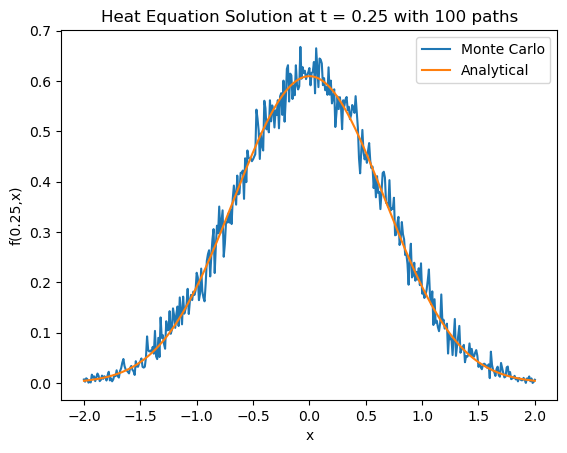

In [171]:
diff = 0.01
t = np.arange(-2, 2 + diff, diff)
paths = 100
x = np.arange(0,.25 + diff, diff)


heat = []
actual = []
for i in t:
    BM = np.cumsum(np.insert(np.random.normal(loc=0,scale=m.sqrt(diff), size=(paths, len(x) - 1)),0,i,axis=1), axis=1)
    heat.append(np.mean(g(BM[:,-1])))
    result, error = integrate.quad(gp,-np.inf,np.inf,args=(i,0.25,))
    actual.append(result)

plt.plot(t,heat, label = "Monte Carlo")
plt.plot(t,actual, label = "Analytical")
plt.title(f"Heat Equation Solution at t = 0.25 with {paths} paths")
plt.xlabel("x")
plt.ylabel("f(0.25,x)")
plt.legend()
plt.show()




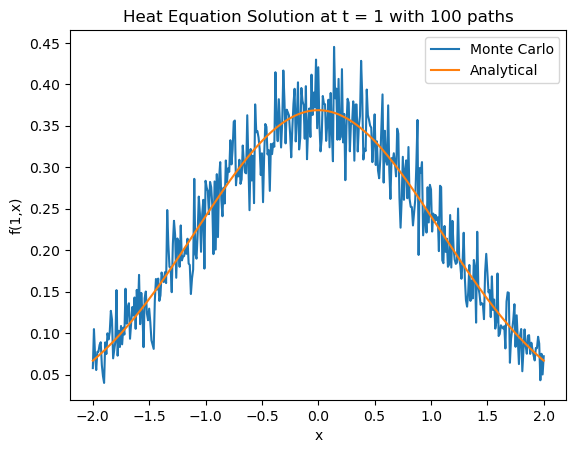

In [172]:
diff = 0.01
t = np.arange(-2, 2 + diff, diff)
paths = 100
x = np.arange(0,1 + diff, diff)


heat = []
actual = []
for i in t:
    BM = np.cumsum(np.insert(np.random.normal(loc=0,scale=m.sqrt(diff), size=(paths, len(x) - 1)),0,i,axis=1), axis=1)
    heat.append(np.mean(g(BM[:,-1])))
    result, error = integrate.quad(gp,-np.inf,np.inf,args=(i,1,))
    actual.append(result)

plt.plot(t,heat, label = "Monte Carlo")
plt.plot(t,actual, label = "Analytical")
plt.title(f"Heat Equation Solution at t = 1 with {paths} paths")
plt.xlabel("x")
plt.ylabel("f(1,x)")
plt.legend()
plt.show()

## 8.3

### a

In [173]:
def sgn(x):
    return np.where(x >= 0, 1, -1)



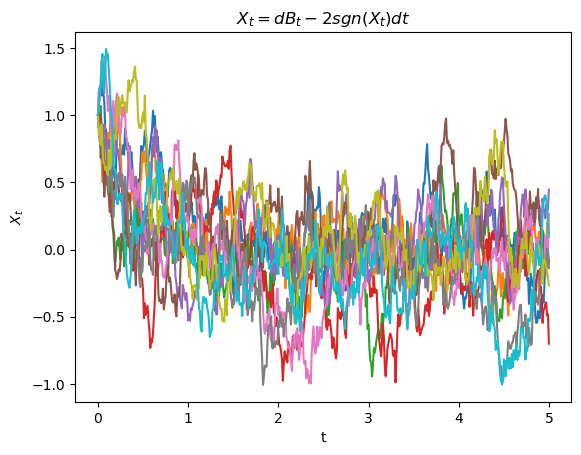

In [174]:
diff = 0.01
x = np.arange(0, 5 + diff, diff)
paths = 10

BM = np.random.normal(loc = 0, scale= m.sqrt(diff), size=(paths, len(x) - 1))


Xt = np.zeros(shape=(paths, len(x)))
Xt[:, 0] = 1

for i in range(len(x)-1):
    Xt[:,i+1] = Xt[:,i] + BM[:,i] - 2 * (sgn(Xt[:,i]) * diff)

plt.plot(x,Xt.T)
plt.title(r"$X_t = dB_t - 2sgn(X_t)dt$")
plt.xlabel('t')
plt.ylabel(r"$X_t$")
plt.show()

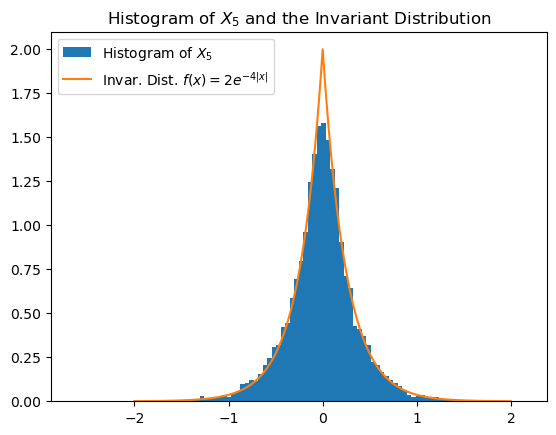

In [175]:
diff = 0.01
x = np.arange(0, 5 + diff, diff)
paths = 10000
plug = np.arange(-2, 2 + diff, diff)
fun = 2 * np.exp(-4 * np.abs(plug))


BM = np.random.normal(loc = 0, scale= m.sqrt(diff), size=(paths, len(x) - 1))


Xt = np.zeros(shape=(paths, len(x)))
Xt[:, 0] = 1

for i in range(len(x)-1):
    Xt[:,i+1] = Xt[:,i] + BM[:,i] - 2 * (sgn(Xt[:,i]) * diff)

# plt.plot(x,Xt.T)
# plt.show()

plt.hist(Xt[:,-1], bins=100, density=True, label=r"Histogram of $X_5$")
plt.title(r"Histogram of $X_5$ and the Invariant Distribution")
plt.plot(plug,fun, label = r"Invar. Dist. $f(x) = 2e^{-4|x|}$")
plt.legend()
plt.show()